In [ ]:
# default_exp paper.cnn.overfitting

# 4.5. Overfitting in action (CNN)

> CNN model performance trained on all Soil Taxonomy Orders and looking at overfitting in action when trained over 200 epochs

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Python utils
import math
from collections import OrderedDict
from tqdm.auto import tqdm
from pathlib import Path
import pickle

# mirzai utilities
from mirzai.data.loading import load_kssl
from mirzai.data.selection import (select_y, select_tax_order, select_X)
from mirzai.data.transform import log_transform_y
from mirzai.training.cnn import (Model, weights_init)
from mirzai.data.torch import (DataLoaders, SNV_transform, SpectralDataset)
from mirzai.training.cnn import Learner
from mirzai.training.metrics import eval_reg
from mirzai.vis.core import (centimeter, PRIMARY_COLOR, 
                             set_style, DEFAULT_STYLE)


from fastcore.transform import compose

# Data science stack
import numpy as np
from sklearn.model_selection import train_test_split

# Data vis.
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from cycler import cycler

# Deep Learning stack
import torch
from torch.nn import MSELoss
from torch.optim import Adam
from torch.optim.lr_scheduler import CyclicLR

import warnings
warnings.filterwarnings('ignore')

## Load and transform

In [ ]:
src_dir = '../_data'
fnames = ['spectra-features.npy', 'spectra-wavenumbers.npy', 
          'depth-order.npy', 'target.npy', 
          'tax-order-lu.pkl', 'spectra-id.npy']

X, X_names, depth_order, y, tax_lookup, X_id = load_kssl(src_dir, fnames=fnames)

data = X, y, X_id, depth_order

transforms = [select_y, select_tax_order, select_X, log_transform_y]
X, y, X_id, depth_order = compose(*transforms)(data)

In [ ]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Wavenumbers:\n {X_names}')
print(f'depth_order (first 3 rows):\n {depth_order[:3, :]}')
print(f'Taxonomic order lookup:\n {tax_lookup}')

X shape: (40132, 1764)
y shape: (40132,)
Wavenumbers:
 [3999 3997 3995 ...  603  601  599]
depth_order (first 3 rows):
 [[43.  2.]
 [ 0.  0.]
 [ 0.  1.]]
Taxonomic order lookup:
 {'alfisols': 0, 'mollisols': 1, 'inceptisols': 2, 'entisols': 3, 'spodosols': 4, 'undefined': 5, 'ultisols': 6, 'andisols': 7, 'histosols': 8, 'oxisols': 9, 'vertisols': 10, 'aridisols': 11, 'gelisols': 12}


## Experiment

### Setup

In [ ]:
# Is a GPU available?
use_cuda = torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
print(f'Runtime is: {device}')

Runtime is: cpu


In [ ]:
seeds = range(20)
criterion = MSELoss() # Mean Squared Error loss
min_epoch, max_epoch = 10, 210
base_lr, max_lr = 3e-5, 1e-3

epoch_inc = 10
step_size_up = 5

if device.type == 'cpu':
    min_epoch, max_epoch = 1, 2
    epoch_inc = 1
    seeds = range(2)
    
tax_of_interest = tax_lookup.copy()
tax_of_interest['all'] = tax_of_interest.pop('oxisols') # Too few Oxisols for now in the KSSL db    

mses_by_order = np.zeros((len(seeds),
                          len(range(min_epoch, max_epoch, epoch_inc)),
                          len(tax_of_interest),
                          2))

### Run

In [ ]:
for seed in tqdm(seeds):
    print("************")
    print('Seed: ', seed)
    
    # 1. Initialize a "fresh" new CNN
    model = Model(X.shape[1], out_channel=16).to(device)
    opt = Adam(model.parameters(), lr=1e-4)
    model = model.apply(weights_init)
    scheduler = CyclicLR(opt, base_lr=base_lr, max_lr=max_lr,
                         step_size_up=step_size_up, mode='triangular',
                         cycle_momentum=False)

    # 2. Starting from min_epoch, train additional 10 epochs then stop when reaching max_epoch 
    for epoch_idx, epoch in enumerate(range(min_epoch, max_epoch, epoch_inc)):
        print('Epoch: ', epoch)
        data = train_test_split(X, y, depth_order, test_size=0.1, random_state=seed)
        X_train, X_test, y_train, y_test, depth_order_train, depth_order_test = data
        dls = DataLoaders(((X_train, y_train), (X_test, y_test)), transform=SNV_transform())
        training_generator, test_generator = dls.loaders()
            
        # Train addition `epoch_inc` epochs
        learner = Learner(model, criterion, opt, n_epochs=epoch_inc, 
                          scheduler=scheduler, verbose=True)
        model, losses = learner.fit(training_generator, test_generator) 
               
        # 3. Evaluate on train & test sets on each Soil Taxonomy orders of interest
        for tax_idx in range(len(tax_of_interest)):
            if tax_idx == 9:
                mask_train = np.ones(len(depth_order_train), dtype=bool)
                mask_test = np.ones(len(depth_order_test), dtype=bool)
            else:
                mask_train = depth_order_train[:, 1] == tax_idx
                mask_test = depth_order_test[:, 1] == tax_idx
            if np.sum(mask_test) != 0: 
                dls = DataLoaders(((X_train[mask_train, :], y_train[mask_train]),
                                   (X_test[mask_test, :], y_test[mask_test])), 
                                  transform=SNV_transform())
                training_set_order, test_set_order = dls.loaders()
                
                y_hat_train, y_true_train = learner.predict(training_set_order)
                mse_train = eval_reg(y_true_train, y_hat_train, is_log=True)['mse']

                y_hat_test, y_true_test = learner.predict(test_set_order)
                mse_test = eval_reg(y_true_test, y_hat_test, is_log=True)['mse']

                mses_by_order[seed, epoch_idx, tax_idx, 0] = mse_train
                mses_by_order[seed, epoch_idx, tax_idx, 1] = mse_test
            else:
                deltas_mse[seed, epoch_idx, tax_idx] = np.nan


  0%|          | 0/2 [00:00<?, ?it/s]

************
Seed:  0
Epoch:  1
Runtime is: cpu


  0%|          | 0/1 [00:00<?, ?it/s]

End of Epoch 1
 Training loss: 0.17831355770860127
 Validation loss: 0.12799924198124144
************
Seed:  1
Epoch:  1
Runtime is: cpu


  0%|          | 0/1 [00:00<?, ?it/s]

End of Epoch 1
 Training loss: 0.15150663420307203
 Validation loss: 0.12314439703902555


In [ ]:
mses_by_order

array([[[[0.26676998, 0.42630336],
         [1.0559932 , 0.53629696],
         [0.44457021, 0.37167731],
         [0.44557086, 0.32989362],
         [0.48853704, 0.2356813 ],
         [1.77577817, 2.15341425],
         [0.1455621 , 0.14533742],
         [0.64842594, 1.8740288 ],
         [3.95839834, 2.84431696],
         [1.1551615 , 1.24531448],
         [0.31966347, 0.2275943 ],
         [1.03907156, 1.98946488],
         [0.81316644, 1.72576702]]],


       [[[0.20134667, 1.04334307],
         [1.09265733, 0.65161353],
         [0.45335633, 0.41281906],
         [0.49227703, 0.1615694 ],
         [0.51906693, 0.45902884],
         [1.91643429, 1.7361933 ],
         [0.16460422, 0.10785567],
         [0.83325446, 0.32019323],
         [4.04967356, 3.03608608],
         [1.2253437 , 1.11574101],
         [0.28521177, 0.4178544 ],
         [1.08240736, 2.01773381],
         [0.97382128, 0.62028509]]]])

## Save

In [ ]:
# dest_dir = Path('nameofyourfolder')
# with open(dest_dir/'mses_by_order_90_10.pickle'), 'wb') as f: 
#     pickle.dump(mses_by_order, f)

## Plot

Using collected `mses` when the CNN is trained over 210 epochs using a GPU.

In [ ]:
min_epoch, max_epoch = 10, 210
epoch_inc = 10

In [ ]:
src_dir = Path('./files/dumps')
mses_by_order = pickle.load(open(src_dir/'mses_by_order_90_10.pickle', "rb"))

In [ ]:
# Calculating MSEtest - MSEtrain
deltas_mse = np.mean(mses_by_order[:, :, :, 1] - mses_by_order[:, :, :, 0], axis=0, keepdims=True)

In [ ]:
def plot_deltas_mse(epochs, deltas, tax_lookup,
                    figsize=(16*centimeter, 10*centimeter), dpi=600):
    # Layout 
    fig = plt.figure(figsize=figsize, dpi=600)
    gs = GridSpec(nrows=1, ncols=1)
    ax = fig.add_subplot(gs[0, 0])

    cc = (cycler(color=[f'C{i}' for i in range(7)]) *
          cycler(linestyle=['-', '--']))

    # Plots
    for tax_label, tax_idx in tax_lookup.items():
        ax.plot(epochs, np.mean(deltas[:,:,tax_idx], axis=0), 
                label=tax_label.capitalize(),
                **list(cc)[tax_idx])

    # Ornaments
    ax.legend(loc='best', frameon=False, ncol=3) 
    ax.set_ylabel('$MSE_{test} - MSE_{train}$ →', loc='top')
    ax.set_xlabel('Number of epochs →', loc='right')
    ax.grid(True, "minor", color="0.85", linewidth=0.2, zorder=-2)
    ax.grid(True, "major", color="0.65", linewidth=0.4, zorder=-1) 
    plt.tight_layout()

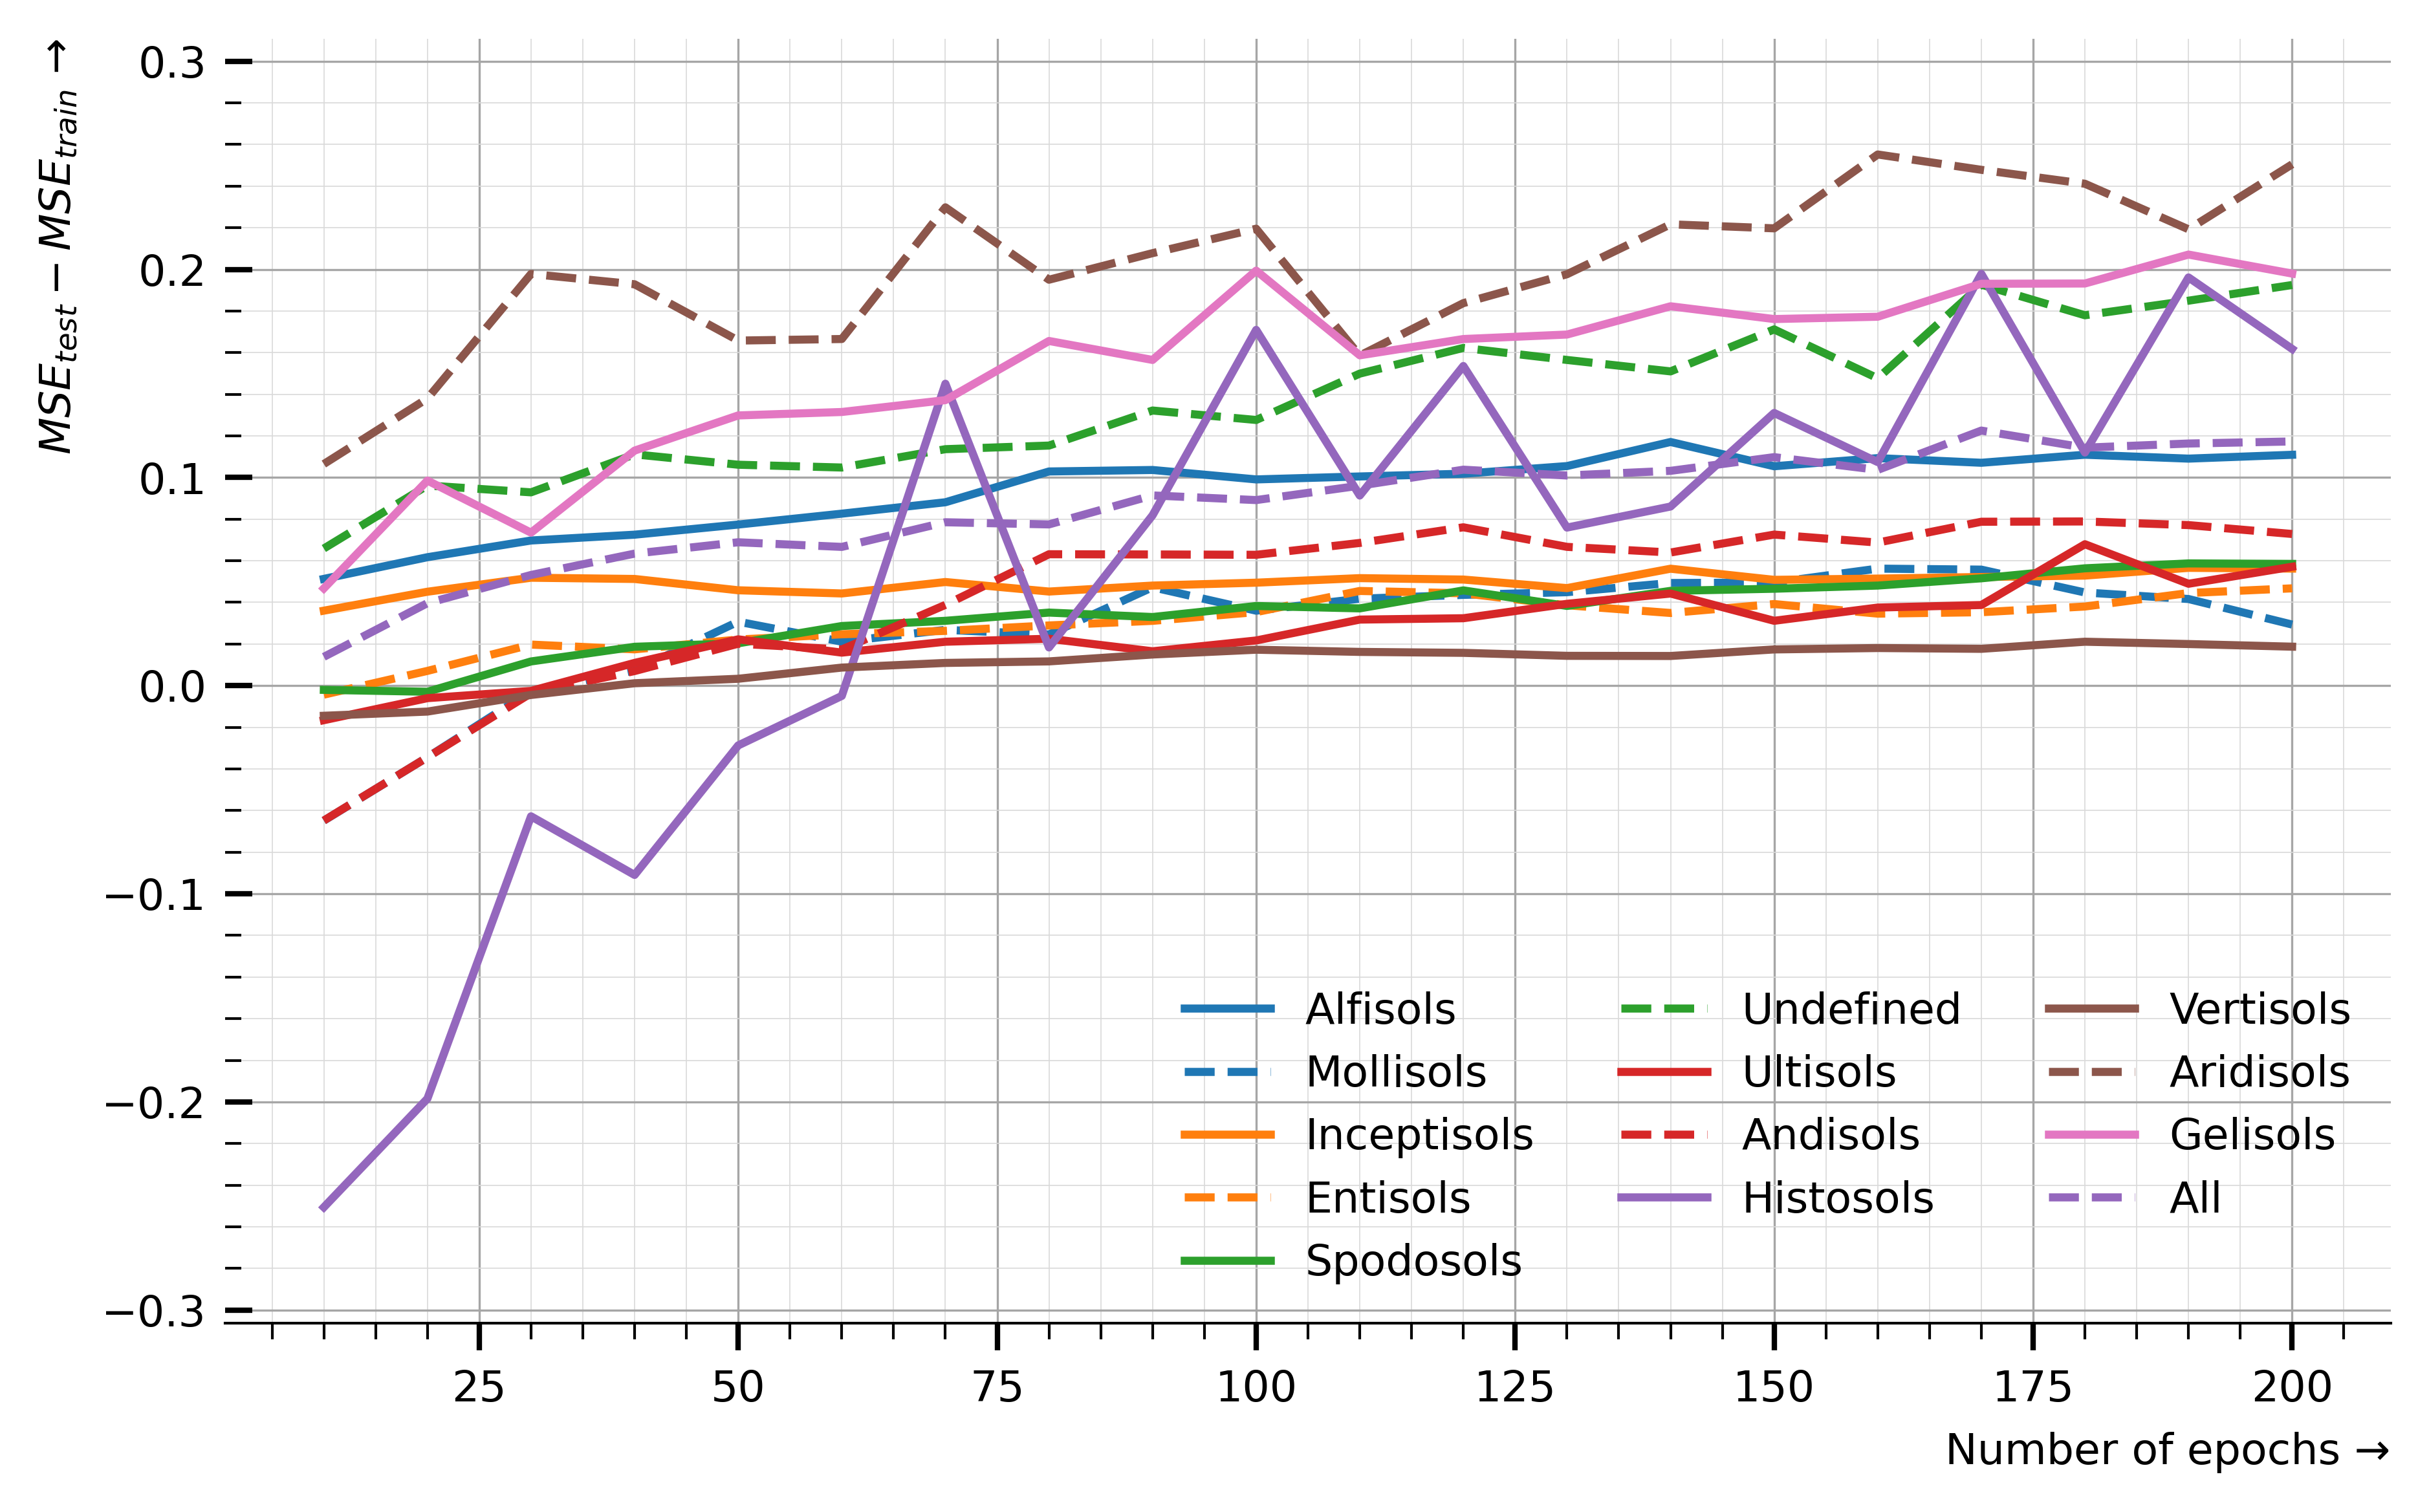

In [ ]:
FIG_PATH = Path('nameofyourfolder')
set_style(DEFAULT_STYLE)
plot_deltas_mse(range(min_epoch, max_epoch, epoch_inc), deltas_mse, tax_of_interest)

# To save/export it
# plt.savefig(FIG_PATH/'deltas_mse.png', dpi=600, transparent=True, format='png')